# Lecture 3b - Connection to the standards: SteamCo Case

Q1) We need some packages to perform the analyses in Python. Import pandas as pd, matplotlib.pyplot as plt, import train_test_split from the sklearn.model_selection library, and import statsmodels.api as sm.

In [1]:
#A1)
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

Q2) Read in the cool_heat_case.csv into an object called cool_heat_case, and have a look at the summary statistics.

In [4]:
#A2) 
cool_heat_case = pd.read_excel(os.path.join(os.getcwd(), "cool_heat_case.xlsx"))
cool_heat_case.describe()

,Date,Revenue,Production_Mlb,Cool_DD,Heat_DD,DDtype
count,48,4.800000e+01,48.000000,48.000000,48.000000,48.000000
mean,2012-12-15 17:00:00,1.403284e+07,493033.833333,113.270833,367.229167,0.500000
min,2011-01-01 00:00:00,4.809952e+06,151104.000000,0.000000,0.000000,0.000000
25%,2011-12-24 06:00:00,1.032580e+07,371474.000000,0.000000,10.500000,0.000000
50%,2012-12-16 12:00:00,1.354276e+07,502280.000000,21.000000,258.500000,0.500000
75%,2013-12-08 18:00:00,1.786524e+07,646926.000000,203.750000,689.250000,1.000000
max,2014-12-01 00:00:00,2.679228e+07,805600.000000,505.000000,1123.000000,1.000000
std,NaN,5.243896e+06,177103.432658,158.473266,359.747325,0.505291


Q3a) Discuss why it is important that a model is tested on never before seen data?

A3a) To assess model fit (prevent over/underfitting) and hence to see if a model generalizes to unseen data.

Q3b) Given this dataset, how would you check how well your model performs on never before seen data?

A3b) Build a model on a trainset and test it on the testset (look at measures of fit such as MSE, MAE, etc.)

Q3c) Create a dataset X containing all variables except the Revenue data, and a dataset y containing only the
Revenue data. Next, split those into train and testsets. To ensure everybody in the class has the same data, please use random_state = 1. 

In [5]:
#A3c) 
X = cool_heat_case.drop(["Revenue"],axis=1)
y = cool_heat_case["Revenue"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

Q3d) Discuss why it is important to split your dataset into a train and testset randomly.

A3d) Because the testset should be representative of the trainset. Taking a random subset is the common way to go about this. For example, if your data is ordered in the dataset with high revenues first and then decreasing, if you would select the first 70% of the rows for your trainset, it would not be representative of your testset anymore.

Q4a) Plot the relationship between Production_Mlb and Revenue as a scatterplot. 

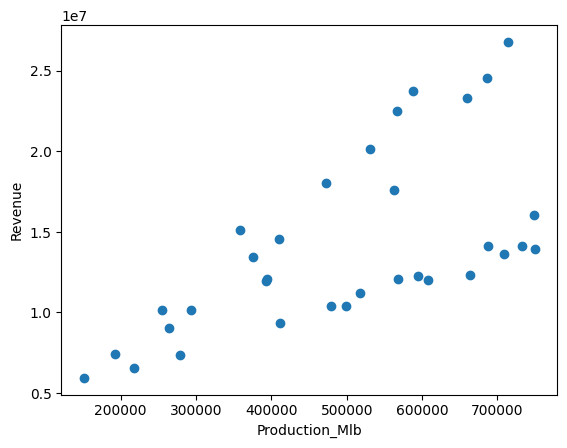

In [6]:
#A4a)
plt.scatter(X_train['Production_Mlb'], y_train)
plt.xlabel('Production_Mlb')
plt.ylabel('Revenue')
plt.show()

Q4b) Given the plot, what model would be suitable to model this relationship?

A4b) A linear regression.

Q4c) Fit the chose model to the data and interpret the results.

In [7]:
# A4c)
X_train = sm.add_constant(X_train['Production_Mlb']) 
linreg = sm.OLS(y_train, X_train).fit()
print(linreg.summary())
print("the intercept is", linreg.params.iloc[0])
print("the coefficient is", linreg.params.iloc[1])

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     21.17
Date:                Wed, 15 May 2024   Prob (F-statistic):           6.71e-05
Time:                        12:15:28   Log-Likelihood:                -549.38
No. Observations:                  33   AIC:                             1103.
Df Residuals:                      31   BIC:                             1106.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             4.4e+06   2.22e+06      1.

Q4d) Discuss what the results of this model mean for the audit question.

A4d) There is a clear relationship between production and revenue. Seeing the firm relationship between the two it seems reasonable to use this relationship as audit evidence. 

Q4e) Given the plot, how would you plot the line of best fit? Plot that line on top of a new scatterplot. 

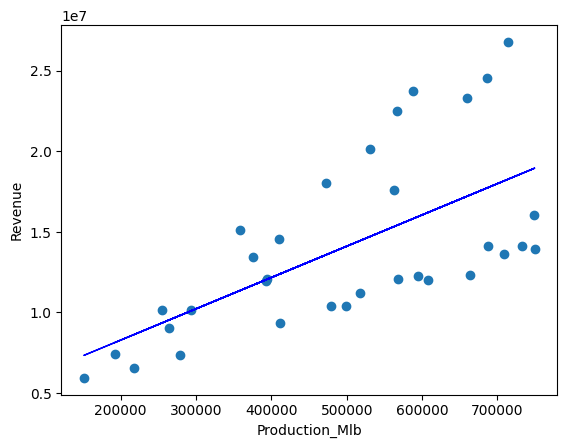

In [8]:
#A4e)
y_pred = linreg.predict(X_train)
plt.scatter(X_train.iloc[:,1], y_train)
plt.plot(X_train.iloc[:,1],y_pred , color='blue', linewidth=1)
plt.xlabel('Production_Mlb')
plt.ylabel('Revenue')
plt.show()

Q5a) What do you think about the fit of the line?

A5a) It does not seem to be a very good fit actually, it looks like there are two patterns of dots, one below and one above. 

Q5b) How can the model better fit the data? (hint: look at the dataset)

A5b) Probably to take into account the heat and cool data separately and fit them separately.

Q5c) Build a new model that better fits the data and interpret the results.

In [9]:
#A5c) First for the cool data.
df_cool = cool_heat_case[cool_heat_case['DDtype']==0]
X_cool = df_cool.drop(["Revenue"],axis=1)
y_cool = df_cool["Revenue"]
X_cool_train, X_cool_test, y_cool_train, y_cool_test = train_test_split(X_cool, y_cool, test_size=0.3, random_state=1)
X_cool_train = sm.add_constant(X_cool_train['Production_Mlb']) 
linreg_cool = sm.OLS(y_cool_train, X_cool_train).fit()
print(linreg_cool.summary())
#print("the cool intercept is", linreg_cool.params.iloc[0])
#print("the cool coefficient is", linreg_cool.params.iloc[1])

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     62.62
Date:                Wed, 15 May 2024   Prob (F-statistic):           1.56e-06
Time:                        12:15:36   Log-Likelihood:                -248.49
No. Observations:                  16   AIC:                             501.0
Df Residuals:                      14   BIC:                             502.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.387e+06   9.89e+05      3.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [10]:
#A5c) Next for the heat data.
df_heat = cool_heat_case[cool_heat_case['DDtype']==1]
X_heat = df_heat.drop(["Revenue"],axis=1)
y_heat = df_heat["Revenue"]
X_heat_train, X_heat_test, y_heat_train, y_heat_test = train_test_split(X_heat, y_heat, test_size=0.3, random_state=1)
X_heat_train = sm.add_constant(X_heat_train['Production_Mlb']) 
linreg_heat = sm.OLS(y_heat_train, X_heat_train).fit()
print(linreg_heat.summary())
#print("the heat intercept is", linreg_heat.params.iloc[0])
#print("the heat coefficient is", linreg_heat.params.iloc[1])

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     187.3
Date:                Wed, 15 May 2024   Prob (F-statistic):           1.70e-09
Time:                        12:15:37   Log-Likelihood:                -248.90
No. Observations:                  16   AIC:                             501.8
Df Residuals:                      14   BIC:                             503.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           8.496e+04   1.31e+06      0.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


Q5d) What is an indication that the model has improved (or not)?

A5d) We can look at R-squared. This has vastly increased now for both models compared to the single regression line.

Q5e) Plot the new results.

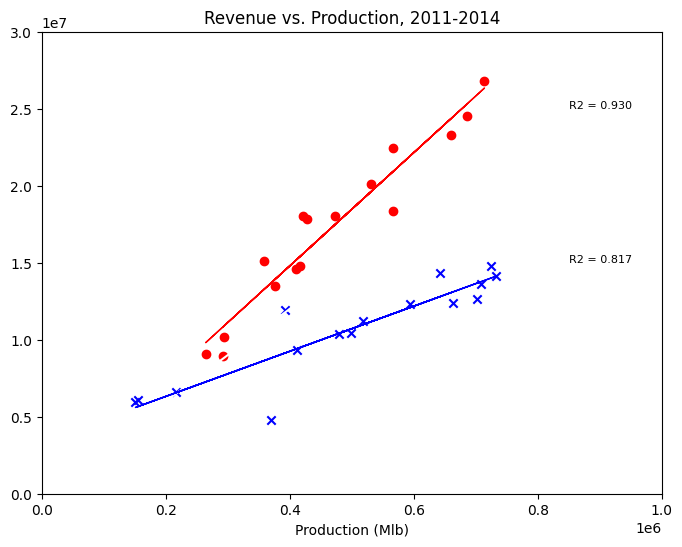

In [11]:
#A5e)
y_cool_pred = linreg_cool.predict(X_cool_train)
y_heat_pred = linreg_heat.predict(X_heat_train)

plt.figure(figsize=(8, 6))
plt.plot([0, 1000000], [0, 30000000], 'w') # plot an empty white canvas
plt.xlim(0, 1000000)
plt.ylim(0, 30000000)

plt.scatter(X_heat_train.iloc[:,1], y_heat_train, color='red')
plt.scatter(X_cool_train.iloc[:,1], y_cool_train, color='blue', marker='x')

plt.plot(X_cool_train.iloc[:,1],y_cool_pred , color='blue', linewidth=1)
plt.plot(X_heat_train.iloc[:,1],y_heat_pred , color='red', linewidth=1)

plt.xlabel('Production (Mlb)')
plt.ylabel('')
plt.title('Revenue vs. Production, 2011-2014')
plt.text(850000, 25000000, 'R2 = 0.930', fontsize=8)
plt.text(850000, 15000000, 'R2 = 0.817', fontsize=8)
plt.show()

Q5f) Represent what is shown on the plot mathematically (hint: write out the two linear regression formulas).

A5f)<br>
For heat: revenue = 84958 + 37 * production_Mlb <br>
For cool: revenue = 3386722 + 15 * production_Mlb

Q6a) Considering the plot, how can the model(s) be improved further?

A6a) It seems that there is an outlier in the data. We could remove that one and fit again.

Q6b) Identify the outlier in the data by calculating a 95% confidence interval.

In [12]:
#6b)
conf_int_cool = linreg_cool.get_prediction(exog=X_cool_train).summary_frame(alpha=0.05)
conf_int_heat = linreg_heat.get_prediction(exog=X_heat_train).summary_frame(alpha=0.05)

# row with ID 21
print(y_cool_train[y_cool_train<conf_int_cool['obs_ci_lower']])
print(X_cool_train[y_cool_train<conf_int_cool['obs_ci_lower']])

# no outliers
print(y_heat_train[y_heat_train<conf_int_heat['obs_ci_lower']])
print(X_heat_train[y_heat_train<conf_int_heat['obs_ci_lower']])

21    4809952
Name: Revenue, dtype: int64
    const  Production_Mlb
21    1.0          369656
Series([], Name: Revenue, dtype: int64)
Empty DataFrame
Columns: [const, Production_Mlb]
Index: []


Q6c) Remove the outlier and fit the model(s) again. What is the difference between the last fits?

In [13]:
#6c)
cool_heat_case_no_outlier = cool_heat_case[cool_heat_case['Date']!='Oct-12']

df_cool = cool_heat_case_no_outlier[cool_heat_case_no_outlier['DDtype']==0]
df_heat = cool_heat_case_no_outlier[cool_heat_case_no_outlier['DDtype']==1]

X_cool = df_cool.drop(["Revenue"],axis=1)
y_cool = df_cool["Revenue"]

X_heat = df_heat.drop(["Revenue"],axis=1)
y_heat = df_heat["Revenue"]

X_cool_train, X_cool_test, y_cool_train, y_cool_test = train_test_split(X_cool, y_cool, test_size=0.3, random_state=1)
X_heat_train, X_heat_test, y_heat_train, y_heat_test = train_test_split(X_heat, y_heat, test_size=0.3, random_state=1)

X_cool_train = sm.add_constant(X_cool_train['Production_Mlb']) 
linreg_cool = sm.OLS(y_cool_train, X_cool_train).fit()
print(linreg_cool.summary())
#print("the cool intercept is", linreg_cool.params.iloc[0])
#print("the cool coefficient is", linreg_cool.params.iloc[1])

X_heat_train = sm.add_constant(X_heat_train['Production_Mlb']) 
linreg_heat = sm.OLS(y_heat_train, X_heat_train).fit()
print(linreg_heat.summary())
#print("the heat intercept is", linreg_heat.params.iloc[0])
#print("the heat coefficient is", linreg_heat.params.iloc[1])

# Nothing changes wrt the heat fit as there were no outliers in that data, the cool R-squared has improved though.

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     62.62
Date:                Wed, 15 May 2024   Prob (F-statistic):           1.56e-06
Time:                        12:16:20   Log-Likelihood:                -248.49
No. Observations:                  16   AIC:                             501.0
Df Residuals:                      14   BIC:                             502.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.387e+06   9.89e+05      3.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


Q6d) Plot the data without outliers, and add both regression lines.

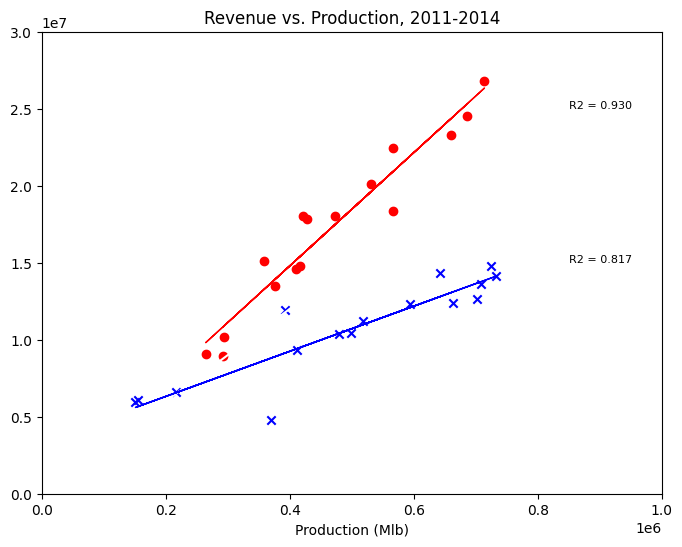

In [14]:
#A6d)
y_cool_pred = linreg_cool.predict(X_cool_train)
y_heat_pred = linreg_heat.predict(X_heat_train)

plt.figure(figsize=(8, 6))
plt.plot([0, 1000000], [0, 30000000], 'w') # plot an empty white canvas
plt.xlim(0, 1000000)
plt.ylim(0, 30000000)

plt.scatter(X_heat_train.iloc[:,1], y_heat_train, color='red')
plt.scatter(X_cool_train.iloc[:,1], y_cool_train, color='blue', marker='x')

plt.plot(X_cool_train.iloc[:,1],y_cool_pred , color='blue', linewidth=1)
plt.plot(X_heat_train.iloc[:,1],y_heat_pred , color='red', linewidth=1)

plt.xlabel('Production (Mlb)')
plt.ylabel('')
plt.title('Revenue vs. Production, 2011-2014')
plt.text(850000, 25000000, 'R2 = 0.930', fontsize=8)
plt.text(850000, 15000000, 'R2 = 0.817', fontsize=8)
plt.show()

Q7a) Now we will be testing our model on the test set. Predict the revenue based on the testset. 

In [15]:
#A7a) 
X_cool_test = sm.add_constant(X_cool_test['Production_Mlb']) 
X_heat_test = sm.add_constant(X_heat_test['Production_Mlb']) 

y_cool_test_pred = linreg_cool.predict(X_cool_test)
y_heat_test_pred = linreg_heat.predict(X_heat_test)

Q7b) Calculate the prediction error by subtracting the predicted revenues from the actual test revenues 

In [16]:
#A7b)
y_cool_test_prediction_error = y_cool_test - y_cool_test_pred
y_heat_test_prediction_error = y_heat_test - y_heat_test_pred

Q7c) Compute the MSE, MAE, and MAPE (mean absolute percentage error) for testset.

In [17]:
#A7c)
#MSE
y_cool_test_MSE = (y_cool_test_prediction_error**2).mean()
y_heat_test_MSE = (y_heat_test_prediction_error**2).mean()
print('y_MSE testset:', 'cool=', y_cool_test_MSE, 'heat=',y_heat_test_MSE)

#MAE
y_cool_test_MAE = (abs(y_cool_test_prediction_error)).mean()
y_heat_test_MAE = (abs(y_heat_test_prediction_error)).mean()
print('y_MAE testset:', 'cool=', y_cool_test_MAE, 'heat=',y_heat_test_MAE)

#MAPE
y_cool_test_MAPE =  (y_cool_test_prediction_error / y_cool_test * 100).abs().mean()
y_heat_test_MAPE =  (y_heat_test_prediction_error / y_heat_test * 100).abs().mean()
print('y_MAPE testset:', 'cool=', y_cool_test_MAPE, 'heat=',y_heat_test_MAPE)


y_MSE testset: cool= 1630796173448.8567 heat= 15445612571418.402
y_MAE testset: cool= 932458.5306068428 heat= 2697458.051693603
y_MAPE testset: cool= 7.471985427932076 heat= 14.736631300838306


Q7d) Compute the MSE, MAE, and MAPE (mean absolute percentage error) for trainset.

In [18]:
#A7d)
y_cool_train_pred = linreg_cool.predict(X_cool_train)
y_heat_train_pred = linreg_heat.predict(X_heat_train)
y_cool_train_prediction_error = y_cool_train - y_cool_train_pred
y_heat_train_prediction_error = y_heat_train - y_heat_train_pred

#MSE
y_cool_train_MSE = (y_cool_train_prediction_error**2).mean()
y_heat_train_MSE = (y_heat_train_prediction_error**2).mean()
print('y_MSE trainset:', 'cool=', y_cool_train_MSE, 'heat=',y_heat_train_MSE)

#MAE
y_cool_train_MAE = (abs(y_cool_train_prediction_error)).mean()
y_heat_train_MAE = (abs(y_heat_train_prediction_error)).mean()
print('y_MAE trainset:', 'cool=', y_cool_train_MAE, 'heat=',y_heat_train_MAE)

#MAPE
y_cool_test_MAPE =  (y_cool_train_prediction_error / y_cool_train * 100).abs().mean()
y_heat_test_MAPE =  (y_heat_train_prediction_error / y_heat_train * 100).abs().mean()
print('y_MAPE trainset:', 'cool=', y_cool_test_MAPE, 'heat=',y_heat_test_MAPE)

y_MSE trainset: cool= 1807445369056.1492 heat= 1902707233585.298
y_MAE trainset: cool= 788500.5277756714 heat= 1168637.808612237
y_MAPE trainset: cool= 9.877618493338513 heat= 7.534652236374301


Q7e) Discuss, what do you think about the fit of the models?

A7e) Fit looks good, seeing that only one variable is used one might worry about underfitting but looking at how well the data and the model compare this seems not to be an issue.